In [1]:
# !pip install geopandas
# !pip install contextily
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import math
import contextily as cx

In [2]:
data_path = "/Users/schoolleila/Documents/01 MCP/03 290 Traffic Safety/final_project/data/"

# Process island and signal data

In [3]:
berk_boundary =gpd.read_file(data_path + "Berkeley_citylimits.geojson")
berk_boundary = berk_boundary.to_crs(epsg=3857)

oak_boundary =gpd.read_file(data_path + "OaklandCityLimits/OaklandCityLimits.shp")
oak_boundary = oak_boundary.to_crs(epsg=3857)

combined_boundary = pd.concat([berk_boundary, oak_boundary], ignore_index=True)
# There will still be two distinct polygons between these two polygons, need to dissolve them into one

In [4]:
# Write function to load in data, clip it by its respective boundary and then combine the Oakland and Berkeley data
def process_data(berk_data_name, oak_data_name):

    # Load data
    berk_data = gpd.read_file(data_path + berk_data_name)
    berk_data = berk_data.to_crs(epsg=3857)

    oak_data = gpd.read_file(data_path + oak_data_name)
    oak_data = oak_data.to_crs(epsg=3857)

    # Perform the clipping operation
    berk_clipped = gpd.clip(berk_data, berk_boundary)
    oak_clipped = gpd.clip(oak_data, oak_boundary)

    # Combine dataframes
    return pd.concat([berk_clipped, oak_clipped])

In [44]:
signal_data = process_data("Berkeley_trafficsignal_after2023_osm.geojson", 
                           "Oakland_trafficsignal_after2023.geojson"
                           )
signal_data

# This looks weird because the data sources are diff so the columns don't match... does it still work though?

DataSourceError: /Users/schoolleila/Documents/01 MCP/03 290 Traffic Safety/final_project/data/Berkeley_trafficsignal_after2023_osm.geojson: No such file or directory

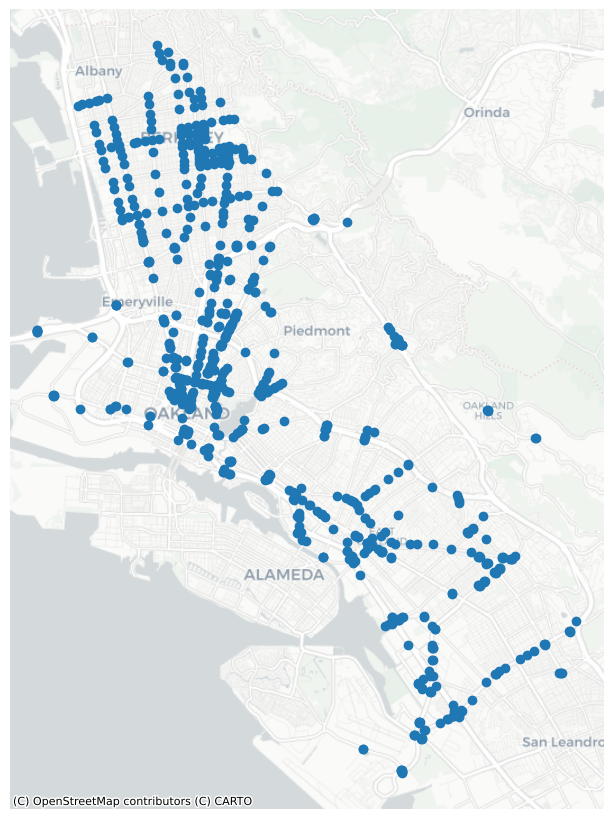

In [6]:
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
signal_data.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

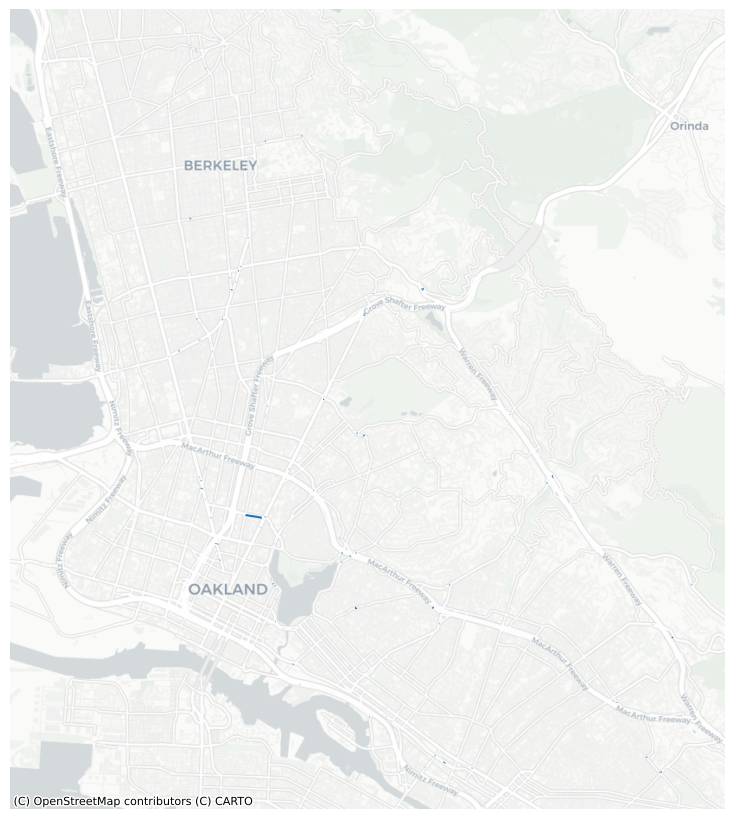

In [7]:
island_data = process_data("Berkeley_islands_after2023.geojson", 
                           "Oakland_islands_after2023.geojson"
                           )

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
island_data.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

## Old method - ignore for now

### Load boundaries

In [8]:
# berk_boundary =gpd.read_file(data_path + "Berkeley_citylimits.geojson")
# berk_boundary = berk_boundary.to_crs(epsg=3857)
# oak_boundary =gpd.read_file(data_path + "OaklandCityLimits/OaklandCityLimits.shp")
# oak_boundary = oak_boundary.to_crs(epsg=3857)

# combined_boundary = pd.concat([berk_boundary, oak_boundary], ignore_index=True)
# combined_boundary
# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# combined_boundary.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

### Load signal data

In [9]:
# berk_signals=gpd.read_file(data_path+"/Berkeley_trafficsignal/Traffic_Light_Intersection.shp")
# berk_signals = berk_signals.to_crs(epsg=3857)

# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# berk_signals.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

In [10]:
# berk_signals['PED_HEAD'].value_counts(dropna=False)

In [11]:
# oak_signals=gpd.read_file(data_path + "Oakland_trafficsignal_after2023.geojson")
# oak_signals = oak_signals.to_crs(epsg=3857)

# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# oak_signals.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

In [12]:
# combined_signals = pd.concat([berk_signals, oak_signals])
# combined_signals.shape

In [13]:
# # combined_signals_gdf = gpd.GeoDataFrame(
# #     combined_signals,
# #     geometry=combined_signals['geometry']
# # )

# if combined_signals.crs != combined_boundary.crs:
#     combined_boundary = combined_boundary.to_crs(combined_signals.crs)

# # Perform the clipping operation
# signals_clipped = gpd.clip(combined_signals, combined_boundary)
# signals_clipped.shape

# # Maybe clip the two cities separately and then combine, since there might be overlap between Berk and Oak

### Load island data

In [14]:
# berk_islands_after2023 =gpd.read_file(data_path + "Berkeley_islands_after2023.geojson")
# berk_islands_after2023 = berk_islands_after2023.to_crs(epsg=3857)

# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# berk_islands_after2023.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

In [15]:
# oak_islands_after2023 =gpd.read_file(data_path + "Oakland_islands_after2023.geojson")
# oak_islands_after2023 = oak_islands_after2023.to_crs(epsg=3857)

# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# oak_islands_after2023.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

In [16]:
# oak_islands_after2023.shape

In [17]:
# oak_islands_gdf = gpd.GeoDataFrame(
#     oak_islands_after2023,
#     geometry=oak_islands_after2023['geometry']
# )

# if oak_islands_gdf.crs != oak_boundary.crs:
#     oak_boundary = oak_boundary.to_crs(oak_islands_gdf.crs)

# # Perform the clipping operation
# oak_islands_clipped = gpd.clip(oak_islands_gdf, oak_boundary)
# oak_islands_clipped.shape

In [18]:
# combined_islands = pd.concat([berk_islands_after2023, oak_islands_after2023])
# combined_islands.shape

In [19]:
# combined_islands_gdf = gpd.GeoDataFrame(
#     combined_islands,
#     geometry=combined_islands['geometry']
# )

# if combined_islands_gdf.crs != combined_boundary.crs:
#     combined_boundary = combined_boundary.to_crs(combined_islands_gdf.crs)

# # Perform the clipping operation
# islands_clipped = gpd.clip(combined_islands_gdf, combined_boundary)
# islands_clipped.shape


# # Maybe clip the two cities separately and then combine, since there might be overlap between Berk and Oak

In [20]:
# len(combined_islands_gdf['id'].unique())

# Load crash data

In [21]:
crash_data = pd.read_csv(data_path + "Oakland_berkeley_crash_SWITRS.csv")

In [22]:
crash_data['PEDESTRIAN_ACCIDENT'].value_counts(dropna=False)

PEDESTRIAN_ACCIDENT
NaN    29439
Y       4411
Name: count, dtype: int64

In [23]:
# Convert date time to date-time format
crash_data['COLLISION_DATE_DT'] = pd.to_datetime(crash_data['COLLISION_DATE'])

In [24]:
# Filter for crashes at intersections and after Jan 1, 2023

crash_filtered = crash_data.loc[
                                (crash_data['PEDESTRIAN_ACCIDENT']=='Y') &
                                (crash_data['COLLISION_DATE']>'2023-01-01')&
                                # ((ped_crashes['CITY']=='OAKLAND')|(ped_crashes['CITY']=='BERKELEY'))&
                                # (ped_crashes['INTERSECTION']=='Y')&
                                (crash_data['DISTANCE']<=10) #Distance less than or equal to 10 ft from intersection
                                ]

# Check date
crash_filtered['COLLISION_DATE'].min()

'2023-01-03'

In [25]:
# Convert crash data into a geodataframe

crash_gdf = gpd.GeoDataFrame(
    crash_filtered, 
    geometry=gpd.points_from_xy(crash_filtered['POINT_X'], crash_filtered['POINT_Y'], 
    crs = 4326)
    )

# crash_gdf = crash_gdf.to_crs(epsg=3857)

# fig = plt.figure(figsize=[12,8])
# ax = fig.add_axes([0, 0, 1, 1])
# crash_gdf.plot(ax=ax)

# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# ax.set_axis_off()

/opt/anaconda3/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 29 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


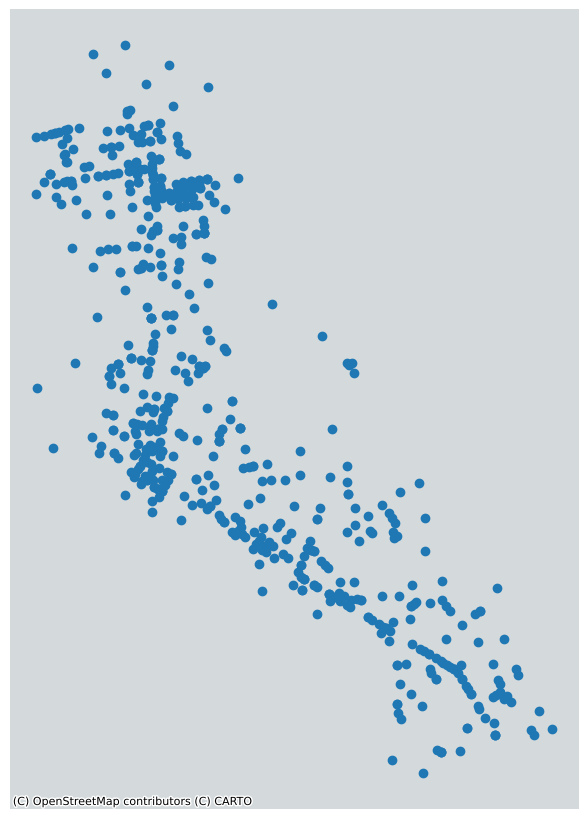

In [26]:
# Clip crash geodataframe by city boundary

# Ensure both datasets are in the same CRS
if crash_gdf.crs != combined_boundary.crs:
    combined_boundary = combined_boundary.to_crs(crash_gdf.crs)

# Perform the clipping operation
crash_clipped = gpd.clip(crash_gdf, combined_boundary)

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
crash_clipped.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

In [27]:
crash_clipped['INTERSECTION'].value_counts(dropna=False)

# There are still almost 100 crashes not "at an intersection" that are included based on distance criteria

INTERSECTION
Y    516
N     91
-      2
Name: count, dtype: int64

array([[<Axes: title={'center': 'DISTANCE'}>]], dtype=object)

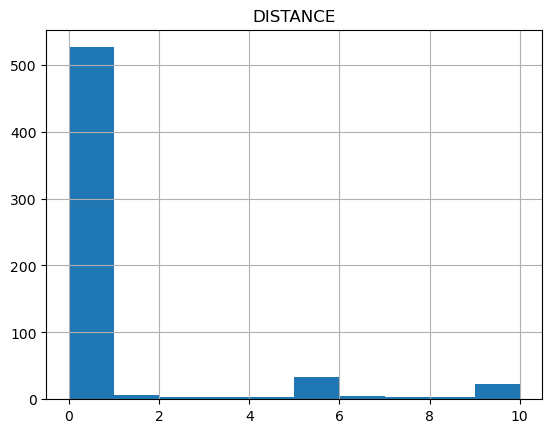

In [28]:
crash_clipped['DISTANCE']
crash_clipped.hist(column='DISTANCE', bins=10)

In [29]:
crash_clipped.loc[crash_gdf['CITY']=='OAKLAND', ['LATITUDE', 'LONGITUDE', 'PRIMARY_RD', 'SECONDARY_RD']]

,LATITUDE,LONGITUDE,PRIMARY_RD,SECONDARY_RD
17796,NaN,NaN,98TH AV,RT 880
10635,NaN,NaN,EDES AV,98TH AV
5185,NaN,NaN,98TH AV,EDES AV
5436,NaN,NaN,98TH AV,EDES AV
24937,NaN,NaN,STONE ST,PIPPIN ST
...,...,...,...,...
24646,NaN,NaN,LA SALLE AV,MORAGA AV
17540,NaN,NaN,LA SALLE AVE,MOUNTAIN BLVD
33849,NaN,NaN,MORAGA AV,MEDAU PL
11005,NaN,NaN,MORAGA AV,ESTATES DR


# Try to associate crashes with islands

In [30]:
island_data

,id,@id,bicycle,foot,footway,highway,lit,motor_vehicle,surface,tactile_paving,geometry,button_operated,crossing:island,informal
17,way/1447913613,way/1447913613,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611094.174 4558435.913, -136110...",NaN,NaN,NaN
16,way/1447913610,way/1447913610,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611106.23 4558444.062, -1361110...",NaN,NaN,NaN
0,way/189026786,way/189026786,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611100.441 4558457.624, -136111...",NaN,NaN,NaN
21,way/1447931291,way/1447931291,permissive,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611132.735 4558617.456, -136111...",NaN,NaN,NaN
15,way/1447908354,way/1447908354,None,yes,traffic_island,footway,None,None,None,None,"LINESTRING (-13611016.417 4558628.058, -136110...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,way/1449284738,way/1449284738,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611567.438 4557270.066, -136115...",None,None,None
5,way/685050158,way/685050158,None,None,traffic_island,footway,None,None,concrete,None,"LINESTRING (-13611810.782 4557333.768, -136118...",None,None,None
76,way/1448353316,way/1448353316,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611517.956 4557095.496, -136115...",None,None,None
78,way/1449281023,way/1449281023,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611779.98 4557715.342, -1361177...",None,None,None


In [31]:
island_data["centroid_geometry"] = island_data.geometry.centroid
island_data

,id,@id,bicycle,foot,footway,highway,lit,motor_vehicle,surface,tactile_paving,geometry,button_operated,crossing:island,informal,centroid_geometry
17,way/1447913613,way/1447913613,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611094.174 4558435.913, -136110...",NaN,NaN,NaN,POINT (-13611092.643 4558434.461)
16,way/1447913610,way/1447913610,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611106.23 4558444.062, -1361110...",NaN,NaN,NaN,POINT (-13611103.825 4558444.049)
0,way/189026786,way/189026786,None,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611100.441 4558457.624, -136111...",NaN,NaN,NaN,POINT (-13611101.504 4558450.921)
21,way/1447931291,way/1447931291,permissive,yes,traffic_island,footway,yes,None,concrete,None,"LINESTRING (-13611132.735 4558617.456, -136111...",NaN,NaN,NaN,POINT (-13611133.909 4558617.402)
15,way/1447908354,way/1447908354,None,yes,traffic_island,footway,None,None,None,None,"LINESTRING (-13611016.417 4558628.058, -136110...",NaN,NaN,NaN,POINT (-13611019.3 4558628.897)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,way/1449284738,way/1449284738,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611567.438 4557270.066, -136115...",None,None,None,POINT (-13611566.191 4557270.207)
5,way/685050158,way/685050158,None,None,traffic_island,footway,None,None,concrete,None,"LINESTRING (-13611810.782 4557333.768, -136118...",None,None,None,POINT (-13611812.822 4557339.062)
76,way/1448353316,way/1448353316,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611517.956 4557095.496, -136115...",None,None,None,POINT (-13611519.281 4557095.214)
78,way/1449281023,way/1449281023,None,None,traffic_island,footway,None,None,None,None,"LINESTRING (-13611779.98 4557715.342, -1361177...",None,None,None,POINT (-13611778.51 4557715.568)


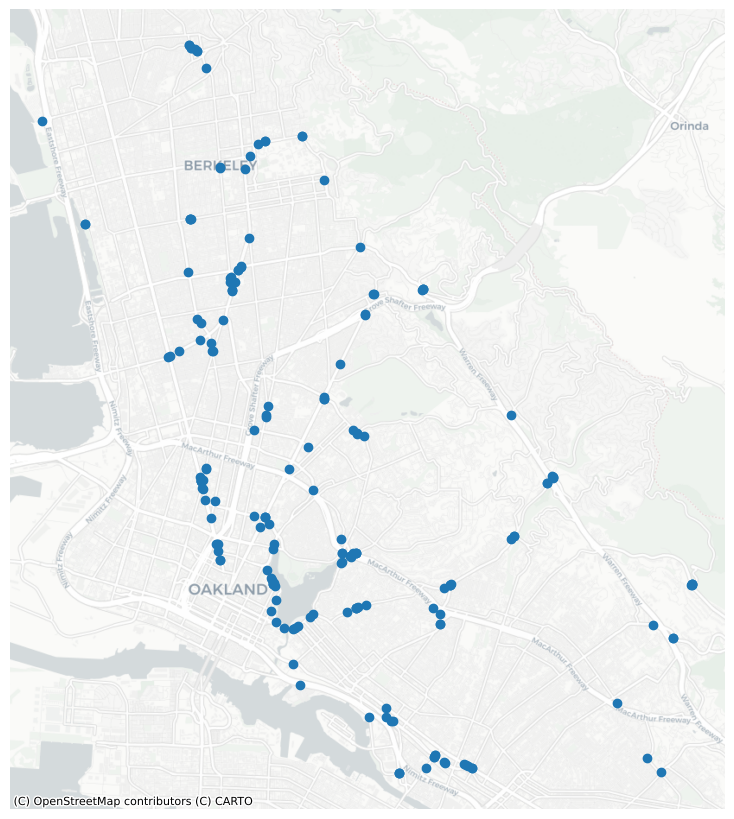

In [32]:
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
island_data['centroid_geometry'].plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

In [33]:
island_data['centroid_buffer'] = island_data['centroid_geometry'].buffer(30)
island_data['centroid_buffer']

17    POLYGON ((-13611062.643 4558434.461, -13611062...
16    POLYGON ((-13611073.825 4558444.049, -13611073...
0     POLYGON ((-13611071.504 4558450.921, -13611071...
21    POLYGON ((-13611103.909 4558617.402, -13611104...
15    POLYGON ((-13610989.3 4558628.897, -13610989.4...
                            ...                        
80    POLYGON ((-13611536.191 4557270.207, -13611536...
5     POLYGON ((-13611782.822 4557339.062, -13611782...
76    POLYGON ((-13611489.281 4557095.214, -13611489...
78    POLYGON ((-13611748.51 4557715.568, -13611748....
77    POLYGON ((-13611835.896 4557808.708, -13611836...
Name: centroid_buffer, Length: 186, dtype: geometry

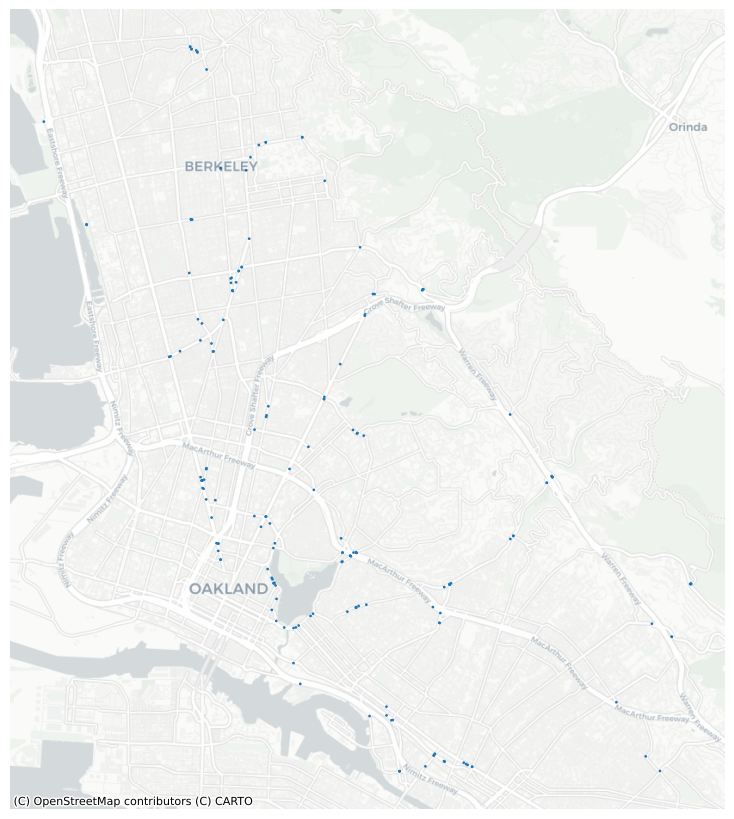

In [34]:
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
island_data['centroid_buffer'].plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

In [35]:
islands_buffer = gpd.GeoDataFrame(
    island_data,
    geometry=island_data['centroid_buffer']
)
islands_buffer.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [36]:
crash_clipped = crash_clipped.to_crs(islands_buffer.crs)

# Spatial join: keeps points within polygon, adds polygon attributes
crashes_within = gpd.sjoin(crash_clipped, islands_buffer, how="inner", 
                        #    predicate='within'
                           )

crashes_within.shape

(38, 98)

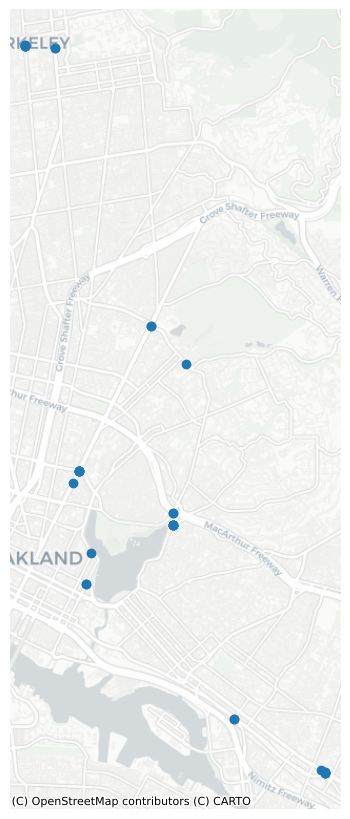

In [37]:
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
crashes_within.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

### DON'T NEED THIS - Testing geocoder

In [41]:
# !pip install geocoder
# import geocoder

In [42]:
# g = geocoder.google('MACARTHUR BL & HIGH ST, OAKLAND')
# print(g.latlng)

In [43]:
# from geopy.geocoders import Nominatim
# geolocator = Nominatim(user_agent="agent", format_string="%s, Oakland, CA")
# location = geolocator.geocode("MACARTHUR BL & HIGH ST")
# print(location.latitude)